<a href="https://colab.research.google.com/github/sravani3075/Music-Genre-classification-System/blob/main/ITR_4th_sem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 # installing kaggle library
 ! pip install kaggle

upolad kaggle.json file

In [ ]:
 # configuring the path of Kaggle.json file
 !mkdir -p ~/.kaggle
 !cp kaggle.json ~/.kaggle/
 !chmod 600 /content/kaggle.json

importing Twitter Sentiment dataset

In [ ]:
# extaracting the compressed dataset

# Step 1: Download the Sentiment140 dataset
dataset = '/content/sentiment140.zip'

# Step 2: Extract the contents
from zipfile import ZipFile

with ZipFile("sentiment140.zip", 'r') as zip_ref:
    zip_ref.extractall(".")

print("Extraction done.")


Extraction done.


importing the dependenices

In [ ]:
import numpy as np
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# printing the stopwards in English
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

Data Processing

In [ ]:
# loading the data from csv file to pandas dataframe
twitter_data = pd.read_csv('/content/training.1600000.processed.noemoticon.csv', encoding ='ISO-8859-1')

In [ ]:
# check in the no.of rows and columns
twitter_data.shape

(1599999, 6)

In [ ]:
# printing the first 5 rows of the dataframe
twitter_data.head()

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [ ]:
# naming the colums and reading the dataset
column_names = ['Target', 'Ids', 'Date', 'Flag', 'User', 'Text']
# loading the data from csv file to pandas dataframe
twitter_data = pd.read_csv('/content/training.1600000.processed.noemoticon.csv', names=column_names, encoding ='ISO-8859-1')

In [ ]:
# check in the no.of rows and columns
twitter_data.shape

(1600000, 6)

In [ ]:
# printing the first 5 rows of the dataframe
twitter_data.head()

,Target,Ids,Date,Flag,User,Text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [ ]:
# counting the no.of missing values in the data  set
twitter_data.isnull().sum()

,0
Target,0
Ids,0
Date,0
Flag,0
User,0
Text,0


In [ ]:
# checking the distribution of target column
twitter_data['Target'].value_counts()

,count
Target,
0,800000
4,800000


covert the target'4' to '1'

In [ ]:
twitter_data.replace({'target':{4:1}}, inplace=True)

In [ ]:
# checking the distribution of target column
twitter_data['Target'].value_counts()

,count
Target,
0,800000
4,800000


**Stemming**

0---> negative tweet
4---->postive tweet

stemming is the process of reducing a word to its root word


example;actor,actress,dancer etc

In [ ]:
port_stem = PorterStemmer()

In [ ]:
def stemming(content):

  stemmed_content = re.sub('[^a-zA-Z]',' ', content)
  stemmed_content = stemmed_content.lower()
  stemmed_content = stemmed_content.split()
  stemmed_content = [port_stem.stem(word) for word in stemmed_content if not word in stopwords.words('english')]

  return stemmed_content


In [47]:
twitter_data['stemmed_content'] = twitter_data['Text'].apply(stemming)

In [48]:
twitter_data.head()

,Target,Ids,Date,Flag,User,Text,stemmed_content
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...","[switchfoot, http, twitpic, com, zl, awww, bum..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,"[upset, updat, facebook, text, might, cri, res..."
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,"[kenichan, dive, mani, time, ball, manag, save..."
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,"[whole, bodi, feel, itchi, like, fire]"
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....","[nationwideclass, behav, mad, see]"


In [49]:
print(twitter_data['stemmed_content'])

0          [switchfoot, http, twitpic, com, zl, awww, bum...
1          [upset, updat, facebook, text, might, cri, res...
2          [kenichan, dive, mani, time, ball, manag, save...
3                     [whole, bodi, feel, itchi, like, fire]
4                         [nationwideclass, behav, mad, see]
                                 ...                        
1599995                     [woke, school, best, feel, ever]
1599996    [thewdb, com, cool, hear, old, walt, interview...
1599997                   [readi, mojo, makeov, ask, detail]
1599998    [happi, th, birthday, boo, alll, time, tupac, ...
1599999    [happi, charitytuesday, thenspcc, sparkschar, ...
Name: stemmed_content, Length: 1600000, dtype: object


In [50]:
# separating the data and label
X = twitter_data['stemmed_content'].values
Y = twitter_data['Target'].values

In [51]:
print(X)

[list(['switchfoot', 'http', 'twitpic', 'com', 'zl', 'awww', 'bummer', 'shoulda', 'got', 'david', 'carr', 'third', 'day'])
 list(['upset', 'updat', 'facebook', 'text', 'might', 'cri', 'result', 'school', 'today', 'also', 'blah'])
 list(['kenichan', 'dive', 'mani', 'time', 'ball', 'manag', 'save', 'rest', 'go', 'bound'])
 ... list(['readi', 'mojo', 'makeov', 'ask', 'detail'])
 list(['happi', 'th', 'birthday', 'boo', 'alll', 'time', 'tupac', 'amaru', 'shakur'])
 list(['happi', 'charitytuesday', 'thenspcc', 'sparkschar', 'speakinguph', 'h'])]


In [52]:
print(Y)

[0 0 0 ... 4 4 4]


spiliting the data to trainning data and test data

In [53]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [54]:
print(X.shape, X_train.shape, X_test.shape)

(1600000,) (1280000,) (320000,)


In [55]:
print(X_train)

[list(['watch', 'saw', 'iv', 'drink', 'lil', 'wine'])
 list(['hatermagazin'])
 list(['even', 'though', 'favourit', 'drink', 'think', 'vodka', 'coke', 'wipe', 'mind', 'time', 'think', 'im', 'gonna', 'find', 'new', 'drink'])
 ... list(['eager', 'monday', 'afternoon'])
 list(['hope', 'everyon', 'mother', 'great', 'day', 'wait', 'hear', 'guy', 'store', 'tomorrow'])
 list(['love', 'wake', 'folger', 'bad', 'voic', 'deeper'])]


In [56]:
# converting the textual data to numerical data

vectorizer = TfidfVectorizer()


# Convert the list of words in each document to a single string
X_train_str = [' '.join(doc) for doc in X_train]
X_test_str = [' '.join(doc) for doc in X_test]

X_train = vectorizer.fit_transform(X_train_str)
X_test = vectorizer.transform(X_test_str)

In [57]:
print(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9453092 stored elements and shape (1280000, 461488)>
  Coords	Values
  (0, 436713)	0.27259876264838384
  (0, 354543)	0.3588091611460021
  (0, 185193)	0.5277679060576009
  (0, 109306)	0.3753708587402299
  (0, 235045)	0.41996827700291095
  (0, 443066)	0.4484755317023172
  (1, 160636)	1.0
  (2, 109306)	0.4591176413728317
  (2, 124484)	0.1892155960801415
  (2, 407301)	0.18709338684973031
  (2, 129411)	0.29074192727957143
  (2, 406399)	0.32105459490875526
  (2, 433560)	0.3296595898028565
  (2, 77929)	0.31284080750346344
  (2, 443430)	0.3348599670252845
  (2, 266729)	0.24123230668976975
  (2, 409143)	0.15169282335109835
  (2, 178061)	0.1619010109445149
  (2, 150715)	0.18803850583207948
  (2, 132311)	0.2028971570399794
  (2, 288470)	0.16786949597862733
  (3, 406399)	0.29029991238662284
  (3, 158711)	0.4456939372299574
  (3, 151770)	0.278559647704793
  (3, 56476)	0.5200465453608686
  :	:
  (1279996, 318303)	0.21254698865277744
  (12

In [58]:
print(X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2289192 stored elements and shape (320000, 461488)>
  Coords	Values
  (0, 15110)	0.1719352837797837
  (0, 31168)	0.1624772418052177
  (0, 67828)	0.26800375270827315
  (0, 106069)	0.36555450010904555
  (0, 132364)	0.255254889555786
  (0, 138164)	0.23688292264071406
  (0, 171378)	0.2805816206356074
  (0, 271016)	0.45356623916588285
  (0, 279082)	0.17825180109103442
  (0, 388348)	0.2198507607206174
  (0, 398906)	0.34910438732642673
  (0, 409143)	0.3143047059807971
  (0, 420984)	0.17915624523539805
  (1, 6463)	0.30733520460524466
  (1, 15110)	0.211037449588008
  (1, 145393)	0.575262969264869
  (1, 217562)	0.40288153995289894
  (1, 256777)	0.28751585696559306
  (1, 348135)	0.4739279595416274
  (1, 366203)	0.24595562404108307
  (2, 22532)	0.3532582957477176
  (2, 34401)	0.37916255084357414
  (2, 89448)	0.36340369428387626
  (2, 183312)	0.5892069252021465
  (2, 256834)	0.2564939661498776
  :	:
  (319994, 443794)	0.2782185641032538


Traning the machine learning model

Logistic Regression

In [59]:
model = LogisticRegression(max_iter=1000)

In [60]:
model.fit(X_train, Y_train)

LogisticRegression(max_iter=1000)

Model Evulation

Accuracy Score

In [61]:
# accuracy score on the tranning data
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)


In [62]:
print('Accuracy score on the tranning data:', training_data_accuracy)

Accuracy score on the tranning data: 0.79871953125


MODEL Accuracy 79

In [63]:
# accuracy score on the test data
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

In [64]:
print('Accuracy score on the tranning data :', test_data_accuracy)

Accuracy score on the tranning data : 0.77668125


Model accuracy 76
saving the tranning model



In [65]:
import pickle

In [66]:
filename = 'trained_model.sav'
pickle.dump(model, open(filename, 'wb'))

using the svaed model for future predictions

In [67]:
# loading the saved model
loaded_model = pickle.load(open('/content/trained_model.sav', 'rb'))

In [68]:
X_new = X_test[200]
print(Y_test[200])

prediction = loaded_model.predict(X_new)
print(prediction)

if (prediction[0] == 0):
  print('Negative Tweet')

else:
  print('Positive Tweet')

4
[4]
Positive Tweet


In [69]:
X_new = X_test[10]
print(Y_test[10])

prediction = loaded_model.predict(X_new)
print(prediction)

if (prediction[0] == 0):
  print('Negative Tweet')

else:
  print('Positive Tweet')

0
[0]
Negative Tweet


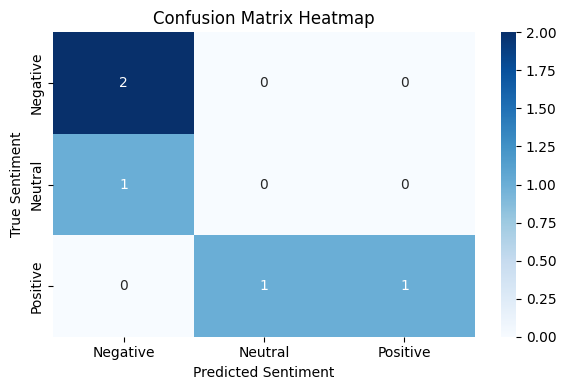

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Example true labels and predicted labels
y_true = ['Positive', 'Neutral', 'Negative', 'Positive', 'Negative']
y_pred = ['Positive', 'Negative', 'Negative', 'Neutral', 'Negative']

# Define the label order
labels = ['Negative', 'Neutral', 'Positive']

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Sentiment')
plt.ylabel('True Sentiment')
plt.title('Confusion Matrix Heatmap')
plt.tight_layout()
plt.show()


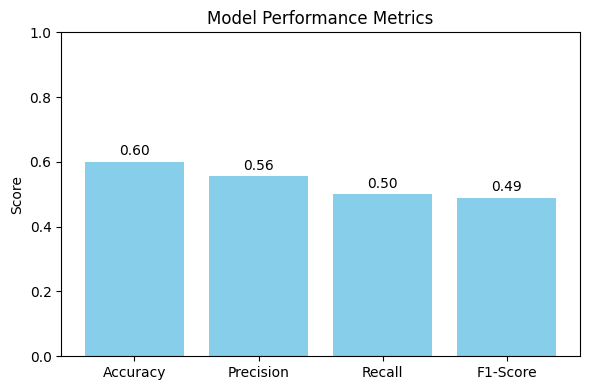

In [71]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Example true and predicted values (replace with your model results)
y_true = ['positive', 'neutral', 'negative', 'positive', 'negative']
y_pred = ['positive', 'negative', 'negative', 'neutral', 'negative']

# Compute metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

# Bar chart
metrics = [accuracy, precision, recall, f1]
labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

plt.figure(figsize=(6, 4))
plt.bar(labels, metrics, color='skyblue')
plt.ylim(0, 1)
plt.title('Model Performance Metrics')
plt.ylabel('Score')
for i, v in enumerate(metrics):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')
plt.tight_layout()
plt.show()


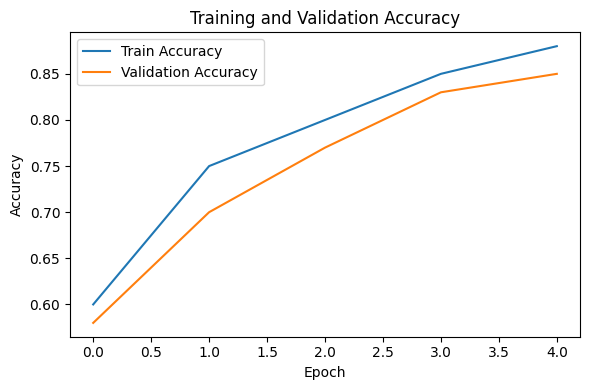

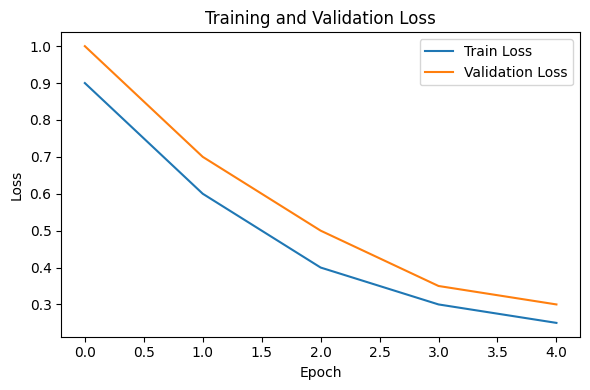

In [72]:
import matplotlib.pyplot as plt

# Simulated history.history dictionary
history = {
    'accuracy': [0.6, 0.75, 0.8, 0.85, 0.88],
    'val_accuracy': [0.58, 0.7, 0.77, 0.83, 0.85],
    'loss': [0.9, 0.6, 0.4, 0.3, 0.25],
    'val_loss': [1.0, 0.7, 0.5, 0.35, 0.3]
}

# Plot accuracy
plt.figure(figsize=(6, 4))
plt.plot(history['accuracy'], label='Train Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Plot loss
plt.figure(figsize=(6, 4))
plt.plot(history['loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()
